In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
from sklearn.utils import resample


In [ ]:
# ─── Plot Style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3a",
    "grid.alpha":       0.6,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   11,
    "axes.labelsize":   9,
})
COLORS = {
    "fraud":     "#ff4d6d",
    "legit":     "#4cc9f0",
    "highlight": "#f8961e",
    "green":     "#43aa8b",
    "purple":    "#9b5de5",
    "blue":      "#4361ee",
    "gradient":  ["#4cc9f0","#4361ee","#7209b7","#f72585"],
}

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1.  SYNTHETIC DATASET GENERATION
# ══════════════════════════════════════════════════════════════
def generate_dataset(n_samples=10000, fraud_ratio=0.07, seed=42):
    np.random.seed(seed)
    n_fraud = int(n_samples * fraud_ratio)
    n_legit = n_samples - n_fraud

    def make_legit(n):
        return pd.DataFrame({
            "transaction_amount":  np.random.lognormal(4.0, 1.0, n),
            "account_age_days":    np.random.randint(30, 3650, n),
            "num_transactions_24h":np.random.poisson(5, n),
            "distance_from_home":  np.abs(np.random.normal(10, 15, n)),
            "transaction_hour":    np.random.randint(6, 23, n),
            "failed_attempts":     np.random.poisson(0.2, n),
            "is_foreign":          np.random.binomial(1, 0.05, n),
            "is_new_device":       np.random.binomial(1, 0.08, n),
            "credit_utilization":  np.clip(np.random.normal(0.35, 0.2, n), 0, 1),
            "avg_txn_amount_30d":  np.random.lognormal(3.8, 0.8, n),
            "is_fraud":            np.zeros(n, int),
        })

    def make_fraud(n):
        return pd.DataFrame({
            "transaction_amount":  np.random.lognormal(5.5, 1.5, n),
            "account_age_days":    np.random.randint(1, 400, n),
            "num_transactions_24h":np.random.poisson(15, n),
            "distance_from_home":  np.abs(np.random.normal(80, 60, n)),
            "transaction_hour":    np.random.choice(list(range(0,6))+list(range(22,24)), n),
            "failed_attempts":     np.random.poisson(2.5, n),
            "is_foreign":          np.random.binomial(1, 0.60, n),
            "is_new_device":       np.random.binomial(1, 0.75, n),
            "credit_utilization":  np.clip(np.random.normal(0.85, 0.15, n), 0, 1),
            "avg_txn_amount_30d":  np.random.lognormal(3.5, 0.9, n),
            "is_fraud":            np.ones(n, int),
        })

    df = pd.concat([make_legit(n_legit), make_fraud(n_fraud)], ignore_index=True)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df

In [ ]:
# ══════════════════════════════════════════════════════════════
# 2.  EDA  —  EXPLORATORY DATA ANALYSIS
# ══════════════════════════════════════════════════════════════
def plot_eda(df, save_path):
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor("#0f1117")
    fig.suptitle("FRAUD DETECTION — EXPLORATORY DATA ANALYSIS",
                 fontsize=16, color="white", fontweight="bold", y=1.01)

    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

    fraud  = df[df["is_fraud"] == 1]
    legit  = df[df["is_fraud"] == 0]

    # 2a  Class Distribution (pie)
    ax = fig.add_subplot(gs[0, 0])
    counts = df["is_fraud"].value_counts()
    ax.pie(counts, labels=["Legitimate", "Fraud"],
           colors=[COLORS["legit"], COLORS["fraud"]],
           autopct="%1.1f%%", startangle=90,
           textprops={"color":"white","fontsize":8},
           wedgeprops={"edgecolor":"#0f1117","linewidth":2})
    ax.set_title("Class Distribution", color="white")

    # 2b  Transaction Amount Distribution
    ax = fig.add_subplot(gs[0, 1])
    ax.hist(np.log1p(legit["transaction_amount"]),  bins=40,
            color=COLORS["legit"],  alpha=0.7, label="Legit", density=True)
    ax.hist(np.log1p(fraud["transaction_amount"]),  bins=40,
            color=COLORS["fraud"],  alpha=0.7, label="Fraud", density=True)
    ax.set_title("Log(Transaction Amount)")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2c  Distance from Home
    ax = fig.add_subplot(gs[0, 2])
    ax.hist(legit["distance_from_home"].clip(0,200), bins=40,
            color=COLORS["legit"], alpha=0.7, label="Legit", density=True)
    ax.hist(fraud["distance_from_home"].clip(0,200), bins=40,
            color=COLORS["fraud"], alpha=0.7, label="Fraud", density=True)
    ax.set_title("Distance from Home (km)")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2d  Credit Utilization
    ax = fig.add_subplot(gs[0, 3])
    ax.hist(legit["credit_utilization"], bins=30,
            color=COLORS["legit"], alpha=0.7, label="Legit", density=True)
    ax.hist(fraud["credit_utilization"], bins=30,
            color=COLORS["fraud"], alpha=0.7, label="Fraud", density=True)
    ax.set_title("Credit Utilization")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2e  Transactions in 24h
    ax = fig.add_subplot(gs[1, 0])
    ax.hist(legit["num_transactions_24h"].clip(0,30), bins=20,
            color=COLORS["legit"], alpha=0.7, label="Legit", density=True)
    ax.hist(fraud["num_transactions_24h"].clip(0,30), bins=20,
            color=COLORS["fraud"], alpha=0.7, label="Fraud", density=True)
    ax.set_title("Transactions in 24h")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2f  Transaction Hour Heatmap-bar
    ax = fig.add_subplot(gs[1, 1])
    hour_fraud = fraud["transaction_hour"].value_counts().sort_index()
    hour_legit = legit["transaction_hour"].value_counts().sort_index()
    ax.bar(hour_legit.index, hour_legit.values / len(legit),
           color=COLORS["legit"], alpha=0.7, label="Legit", width=0.5)
    ax.bar(hour_fraud.index, hour_fraud.values / len(fraud),
           color=COLORS["fraud"], alpha=0.7, label="Fraud", width=0.5)
    ax.set_title("Transaction Hour")
    ax.set_xlabel("Hour of Day")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2g  Failed Attempts
    ax = fig.add_subplot(gs[1, 2])
    ax.hist(legit["failed_attempts"].clip(0,10), bins=10,
            color=COLORS["legit"], alpha=0.7, label="Legit", density=True)
    ax.hist(fraud["failed_attempts"].clip(0,10), bins=10,
            color=COLORS["fraud"], alpha=0.7, label="Fraud", density=True)
    ax.set_title("Failed Login Attempts")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2h  Correlation Heatmap
    ax = fig.add_subplot(gs[1, 3])
    corr = df.corr()
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True
    sns.heatmap(corr, ax=ax, cmap="coolwarm", annot=False,
                linewidths=0.3, linecolor="#0f1117",
                cbar_kws={"shrink":0.7})
    ax.set_title("Feature Correlation")
    ax.tick_params(labelsize=6, rotation=45)

    # 2i  Boxplot — Account Age
    ax = fig.add_subplot(gs[2, 0])
    data_box = [legit["account_age_days"].values, fraud["account_age_days"].values]
    bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", linewidth=2))
    bp["boxes"][0].set_facecolor(COLORS["legit"])
    bp["boxes"][1].set_facecolor(COLORS["fraud"])
    ax.set_xticklabels(["Legit","Fraud"])
    ax.set_title("Account Age (days)")
    ax.grid(True)

    # 2j  Stacked Bar — Binary Features
    ax = fig.add_subplot(gs[2, 1])
    features = ["is_foreign", "is_new_device"]
    x = np.arange(len(features))
    w = 0.3
    fraud_rates  = [fraud[f].mean() for f in features]
    legit_rates  = [legit[f].mean() for f in features]
    ax.bar(x - w/2, legit_rates,  width=w, color=COLORS["legit"],  label="Legit")
    ax.bar(x + w/2, fraud_rates,  width=w, color=COLORS["fraud"],  label="Fraud")
    ax.set_xticks(x)
    ax.set_xticklabels(["Foreign\nTxn","New\nDevice"], fontsize=8)
    ax.set_title("Binary Feature Rates")
    ax.set_ylabel("Proportion")
    ax.legend(fontsize=7)
    ax.grid(True, axis="y")

    # 2k  Avg Txn Amount 30 days
    ax = fig.add_subplot(gs[2, 2])
    ax.hist(np.log1p(legit["avg_txn_amount_30d"]), bins=35,
            color=COLORS["legit"], alpha=0.7, label="Legit", density=True)
    ax.hist(np.log1p(fraud["avg_txn_amount_30d"]), bins=35,
            color=COLORS["fraud"], alpha=0.7, label="Fraud", density=True)
    ax.set_title("Log(Avg Txn 30d)")
    ax.legend(fontsize=7)
    ax.grid(True)

    # 2l  Stats Table
    ax = fig.add_subplot(gs[2, 3])
    ax.axis("off")
    stats = [
        ["Total Records",       f"{len(df):,}"],
        ["Fraud Cases",         f"{df['is_fraud'].sum():,}"],
        ["Legitimate Cases",    f"{(df['is_fraud']==0).sum():,}"],
        ["Fraud Rate",          f"{df['is_fraud'].mean()*100:.1f}%"],
        ["Avg Fraud Amount",    f"${fraud['transaction_amount'].mean():,.0f}"],
        ["Avg Legit Amount",    f"${legit['transaction_amount'].mean():,.0f}"],
        ["Features",            "10"],
    ]
    tbl = ax.table(cellText=stats, colLabels=["Metric","Value"],
                   loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for (r,c), cell in tbl.get_celld().items():
        cell.set_facecolor("#1e2130" if r % 2 == 0 else "#252840")
        cell.set_edgecolor("#333")
        cell.set_text_props(color="white")
    ax.set_title("Dataset Summary", color="white", pad=10)

    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor="#0f1117")
    plt.close()
    print(f"  [✓] EDA saved → {save_path}")



In [ ]:
# ══════════════════════════════════════════════════════════════
# 3.  PREPROCESSING  &  CLASS BALANCING
# ══════════════════════════════════════════════════════════════
def preprocess(df):
    features = [
        "transaction_amount","account_age_days","num_transactions_24h",
        "distance_from_home","transaction_hour","failed_attempts",
        "is_foreign","is_new_device","credit_utilization","avg_txn_amount_30d"
    ]
    X = df[features].copy()
    y = df["is_fraud"].values

    # Log-transform skewed columns
    for col in ["transaction_amount","distance_from_home","avg_txn_amount_30d"]:
        X[col] = np.log1p(X[col])

    X_arr = X.values
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_arr, y, test_size=0.2, stratify=y, random_state=42)

    # Oversample fraud rows by index to avoid label misalignment
    fraud_idx = np.where(y_train == 1)[0]
    legit_idx = np.where(y_train == 0)[0]
    up_idx    = resample(fraud_idx, replace=True,
                         n_samples=len(legit_idx)//2, random_state=42)
    all_idx   = np.concatenate([legit_idx, up_idx])
    rng       = np.random.default_rng(42); rng.shuffle(all_idx)

    X_train_b = X_train_raw[all_idx]
    y_train_b = y_train[all_idx]

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_b)
    X_test_s  = scaler.transform(X_test_raw)

    return X_train_s, X_test_s, y_train_b, y_test, features, scaler



In [ ]:
# ══════════════════════════════════════════════════════════════
# 4.  MODEL TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════
def train_models(X_train, X_test, y_train, y_test):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=12,
                                                       class_weight="balanced", random_state=42),
        "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                                            max_depth=5, random_state=42),
    }
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred   = model.predict(X_test)
        y_proba  = model.predict_proba(X_test)[:, 1]
        roc      = roc_auc_score(y_test, y_proba)
        ap       = average_precision_score(y_test, y_proba)
        cv       = cross_val_score(model, X_train, y_train,
                                   cv=5, scoring="roc_auc").mean()
        results[name] = {
            "model":   model, "y_pred": y_pred, "y_proba": y_proba,
            "roc_auc": roc,   "avg_precision": ap, "cv_auc": cv,
            "report":  classification_report(y_test, y_pred, output_dict=True),
            "cm":      confusion_matrix(y_test, y_pred),
        }
        print(f"  [{name}]  ROC-AUC={roc:.4f}  AP={ap:.4f}  CV-AUC={cv:.4f}")
    return results


In [ ]:
# ══════════════════════════════════════════════════════════════
# 5.  RESULTS  VISUALISATION
# ══════════════════════════════════════════════════════════════
def plot_results(results, y_test, feature_names, save_path):
    fig = plt.figure(figsize=(22, 16))
    fig.patch.set_facecolor("#0f1117")
    fig.suptitle("FRAUD DETECTION — MODEL EVALUATION DASHBOARD",
                 fontsize=16, color="white", fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

    model_names = list(results.keys())
    palette = [COLORS["legit"], COLORS["highlight"], COLORS["fraud"], COLORS["purple"]]

    # 5a  ROC Curves
    ax = fig.add_subplot(gs[0, :2])
    for (name, res), color in zip(results.items(), palette):
        fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{name}  (AUC={res['roc_auc']:.3f})")
    ax.plot([0,1],[0,1],"--", color="#555", lw=1)
    ax.set_title("ROC Curves — All Models")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True)
    ax.set_facecolor("#1a1d27")

    # 5b  Precision-Recall Curves
    ax = fig.add_subplot(gs[0, 2:])
    for (name, res), color in zip(results.items(), palette):
        prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
        ax.plot(rec, prec, color=color, lw=2,
                label=f"{name}  (AP={res['avg_precision']:.3f})")
    ax.set_title("Precision-Recall Curves")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True)
    ax.set_facecolor("#1a1d27")

    # 5c-5f  Confusion Matrices
    for idx, (name, res) in enumerate(results.items()):
        ax = fig.add_subplot(gs[1, idx])
        cm = res["cm"]
        sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                    cmap=sns.light_palette(palette[idx], as_cmap=True),
                    linewidths=1, linecolor="#0f1117",
                    annot_kws={"size":10,"color":"white"},
                    cbar=False)
        ax.set_title(f"{name}\nROC={res['roc_auc']:.3f}", fontsize=9)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticklabels(["Legit","Fraud"], fontsize=8)
        ax.set_yticklabels(["Legit","Fraud"], fontsize=8, rotation=0)

    # 5g  Bar comparison — ROC AUC
    ax = fig.add_subplot(gs[2, 0])
    aucs = [res["roc_auc"] for res in results.values()]
    bars = ax.barh(model_names, aucs, color=palette, edgecolor="#0f1117", height=0.5)
    ax.set_xlim(0.8, 1.0)
    for bar, val in zip(bars, aucs):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8, color="white")
    ax.set_title("ROC-AUC Comparison")
    ax.set_xlabel("ROC-AUC Score")
    ax.grid(True, axis="x")
    ax.set_facecolor("#1a1d27")

    # 5h  Feature Importance (Random Forest)
    ax = fig.add_subplot(gs[2, 1])
    rf = results["Random Forest"]["model"]
    importances = rf.feature_importances_
    indices     = np.argsort(importances)
    ax.barh([feature_names[i] for i in indices], importances[indices],
            color=[COLORS["fraud"] if importances[i] > np.median(importances)
                   else COLORS["blue"] for i in indices])
    ax.set_title("Feature Importance\n(Random Forest)")
    ax.grid(True, axis="x")
    ax.set_facecolor("#1a1d27")

    # 5i  Metrics Summary Table
    ax = fig.add_subplot(gs[2, 2:])
    ax.axis("off")
    rows = []
    for name, res in results.items():
        r = res["report"]
        rows.append([
            name,
            f"{r['1']['precision']:.3f}",
            f"{r['1']['recall']:.3f}",
            f"{r['1']['f1-score']:.3f}",
            f"{res['roc_auc']:.3f}",
            f"{res['cv_auc']:.3f}",
        ])
    cols = ["Model","Precision\n(Fraud)","Recall\n(Fraud)",
            "F1-Score\n(Fraud)","ROC-AUC","CV-AUC"]
    tbl = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 2.0)
    for (r,c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#2d3561")
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#1e2130" if r%2==0 else "#252840")
            cell.set_text_props(color="white")
        cell.set_edgecolor("#333")
    ax.set_title("Model Performance Summary", color="white", pad=15, fontsize=11)

    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.close()
    print(f"  [✓] Results saved → {save_path}")


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.  FRAUD PROBABILITY DISTRIBUTION
# ══════════════════════════════════════════════════════════════
def plot_score_distribution(results, y_test, save_path):
    best_name = max(results, key=lambda n: results[n]["roc_auc"])
    best      = results[best_name]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#0f1117")
    fig.suptitle(f"FRAUD SCORE DISTRIBUTION  —  {best_name}",
                 color="white", fontsize=13, fontweight="bold")

    for ax in axes:
        ax.set_facecolor("#1a1d27")

    # Score distribution
    ax = axes[0]
    proba = best["y_proba"]
    ax.hist(proba[y_test==0], bins=50, color=COLORS["legit"],
            alpha=0.7, density=True, label="Legitimate")
    ax.hist(proba[y_test==1], bins=50, color=COLORS["fraud"],
            alpha=0.7, density=True, label="Fraud")
    ax.axvline(0.5, color="white", linestyle="--", lw=1.5, label="Threshold=0.5")
    ax.set_title("Predicted Fraud Probability")
    ax.set_xlabel("P(Fraud)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(True)

    # Threshold vs Precision/Recall
    ax = axes[1]
    thresholds = np.linspace(0.1, 0.9, 100)
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        tp = ((preds==1)&(y_test==1)).sum()
        fp = ((preds==1)&(y_test==0)).sum()
        fn = ((preds==0)&(y_test==1)).sum()
        p  = tp/(tp+fp) if (tp+fp) > 0 else 0
        r  = tp/(tp+fn) if (tp+fn) > 0 else 0
        f  = 2*p*r/(p+r) if (p+r) > 0 else 0
        precisions.append(p); recalls.append(r); f1s.append(f)
    ax.plot(thresholds, precisions, color=COLORS["legit"],  lw=2, label="Precision")
    ax.plot(thresholds, recalls,    color=COLORS["fraud"],  lw=2, label="Recall")
    ax.plot(thresholds, f1s,        color=COLORS["highlight"], lw=2, label="F1-Score")
    best_t = thresholds[np.argmax(f1s)]
    ax.axvline(best_t, color="white", linestyle="--", lw=1.5,
               label=f"Best Threshold={best_t:.2f}")
    ax.set_title("Threshold vs Metrics")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="#0f1117")
    plt.close()
    print(f"  [✓] Score distribution saved → {save_path}")


In [6]:


# ══════════════════════════════════════════════════════════════
# 7.  MAIN
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("   FRAUD ANALYSIS PROJECT — AI & ML PIPELINE")
print("="*60)

print("\n[1] Generating synthetic transaction dataset...")
df = generate_dataset(n_samples=12000, fraud_ratio=0.07)
print(f"    Dataset shape : {df.shape}")
print(f"    Fraud cases   : {df['is_fraud'].sum()} ({df['is_fraud'].mean()*100:.1f}%)")

print("\n[2] Running Exploratory Data Analysis...")
plot_eda(df, "/content/eda.png")

print("\n[3] Preprocessing & balancing data...")
X_train, X_test, y_train, y_test, features, scaler = preprocess(df)
print(f"    Train shape: {X_train.shape}  |  Test shape: {X_test.shape}")

print("\n[4] Training models...")
results = train_models(X_train, X_test, y_train, y_test)

print("\n[5] Plotting evaluation dashboard...")
plot_results(results, y_test, features, "/content/results.png")

print("\n[6] Plotting score distribution...")
plot_score_distribution(results, y_test, "/content/scores.png")

best = max(results, key=lambda n: results[n]["roc_auc"])
print("\n" + "="*60)
print(f"   BEST MODEL : {best}")
print(f"   ROC-AUC    : {results[best]['roc_auc']:.4f}")
print(f"   CV-AUC     : {results[best]['cv_auc']:.4f}")
print("="*60 + "\n")


   FRAUD ANALYSIS PROJECT — AI & ML PIPELINE

[1] Generating synthetic transaction dataset...
    Dataset shape : (12000, 11)
    Fraud cases   : 840 (7.0%)

[2] Running Exploratory Data Analysis...
  [✓] EDA saved → /content/eda.png

[3] Preprocessing & balancing data...
    Train shape: (13392, 10)  |  Test shape: (2400, 10)

[4] Training models...
  [Logistic Regression]  ROC-AUC=1.0000  AP=0.9998  CV-AUC=1.0000
  [Decision Tree]  ROC-AUC=0.9851  AP=0.9723  CV-AUC=0.9996
  [Random Forest]  ROC-AUC=1.0000  AP=1.0000  CV-AUC=1.0000
  [Gradient Boosting]  ROC-AUC=0.9999  AP=0.9991  CV-AUC=1.0000

[5] Plotting evaluation dashboard...
  [✓] Results saved → /content/results.png

[6] Plotting score distribution...
  [✓] Score distribution saved → /content/scores.png

   BEST MODEL : Random Forest
   ROC-AUC    : 1.0000
   CV-AUC     : 1.0000



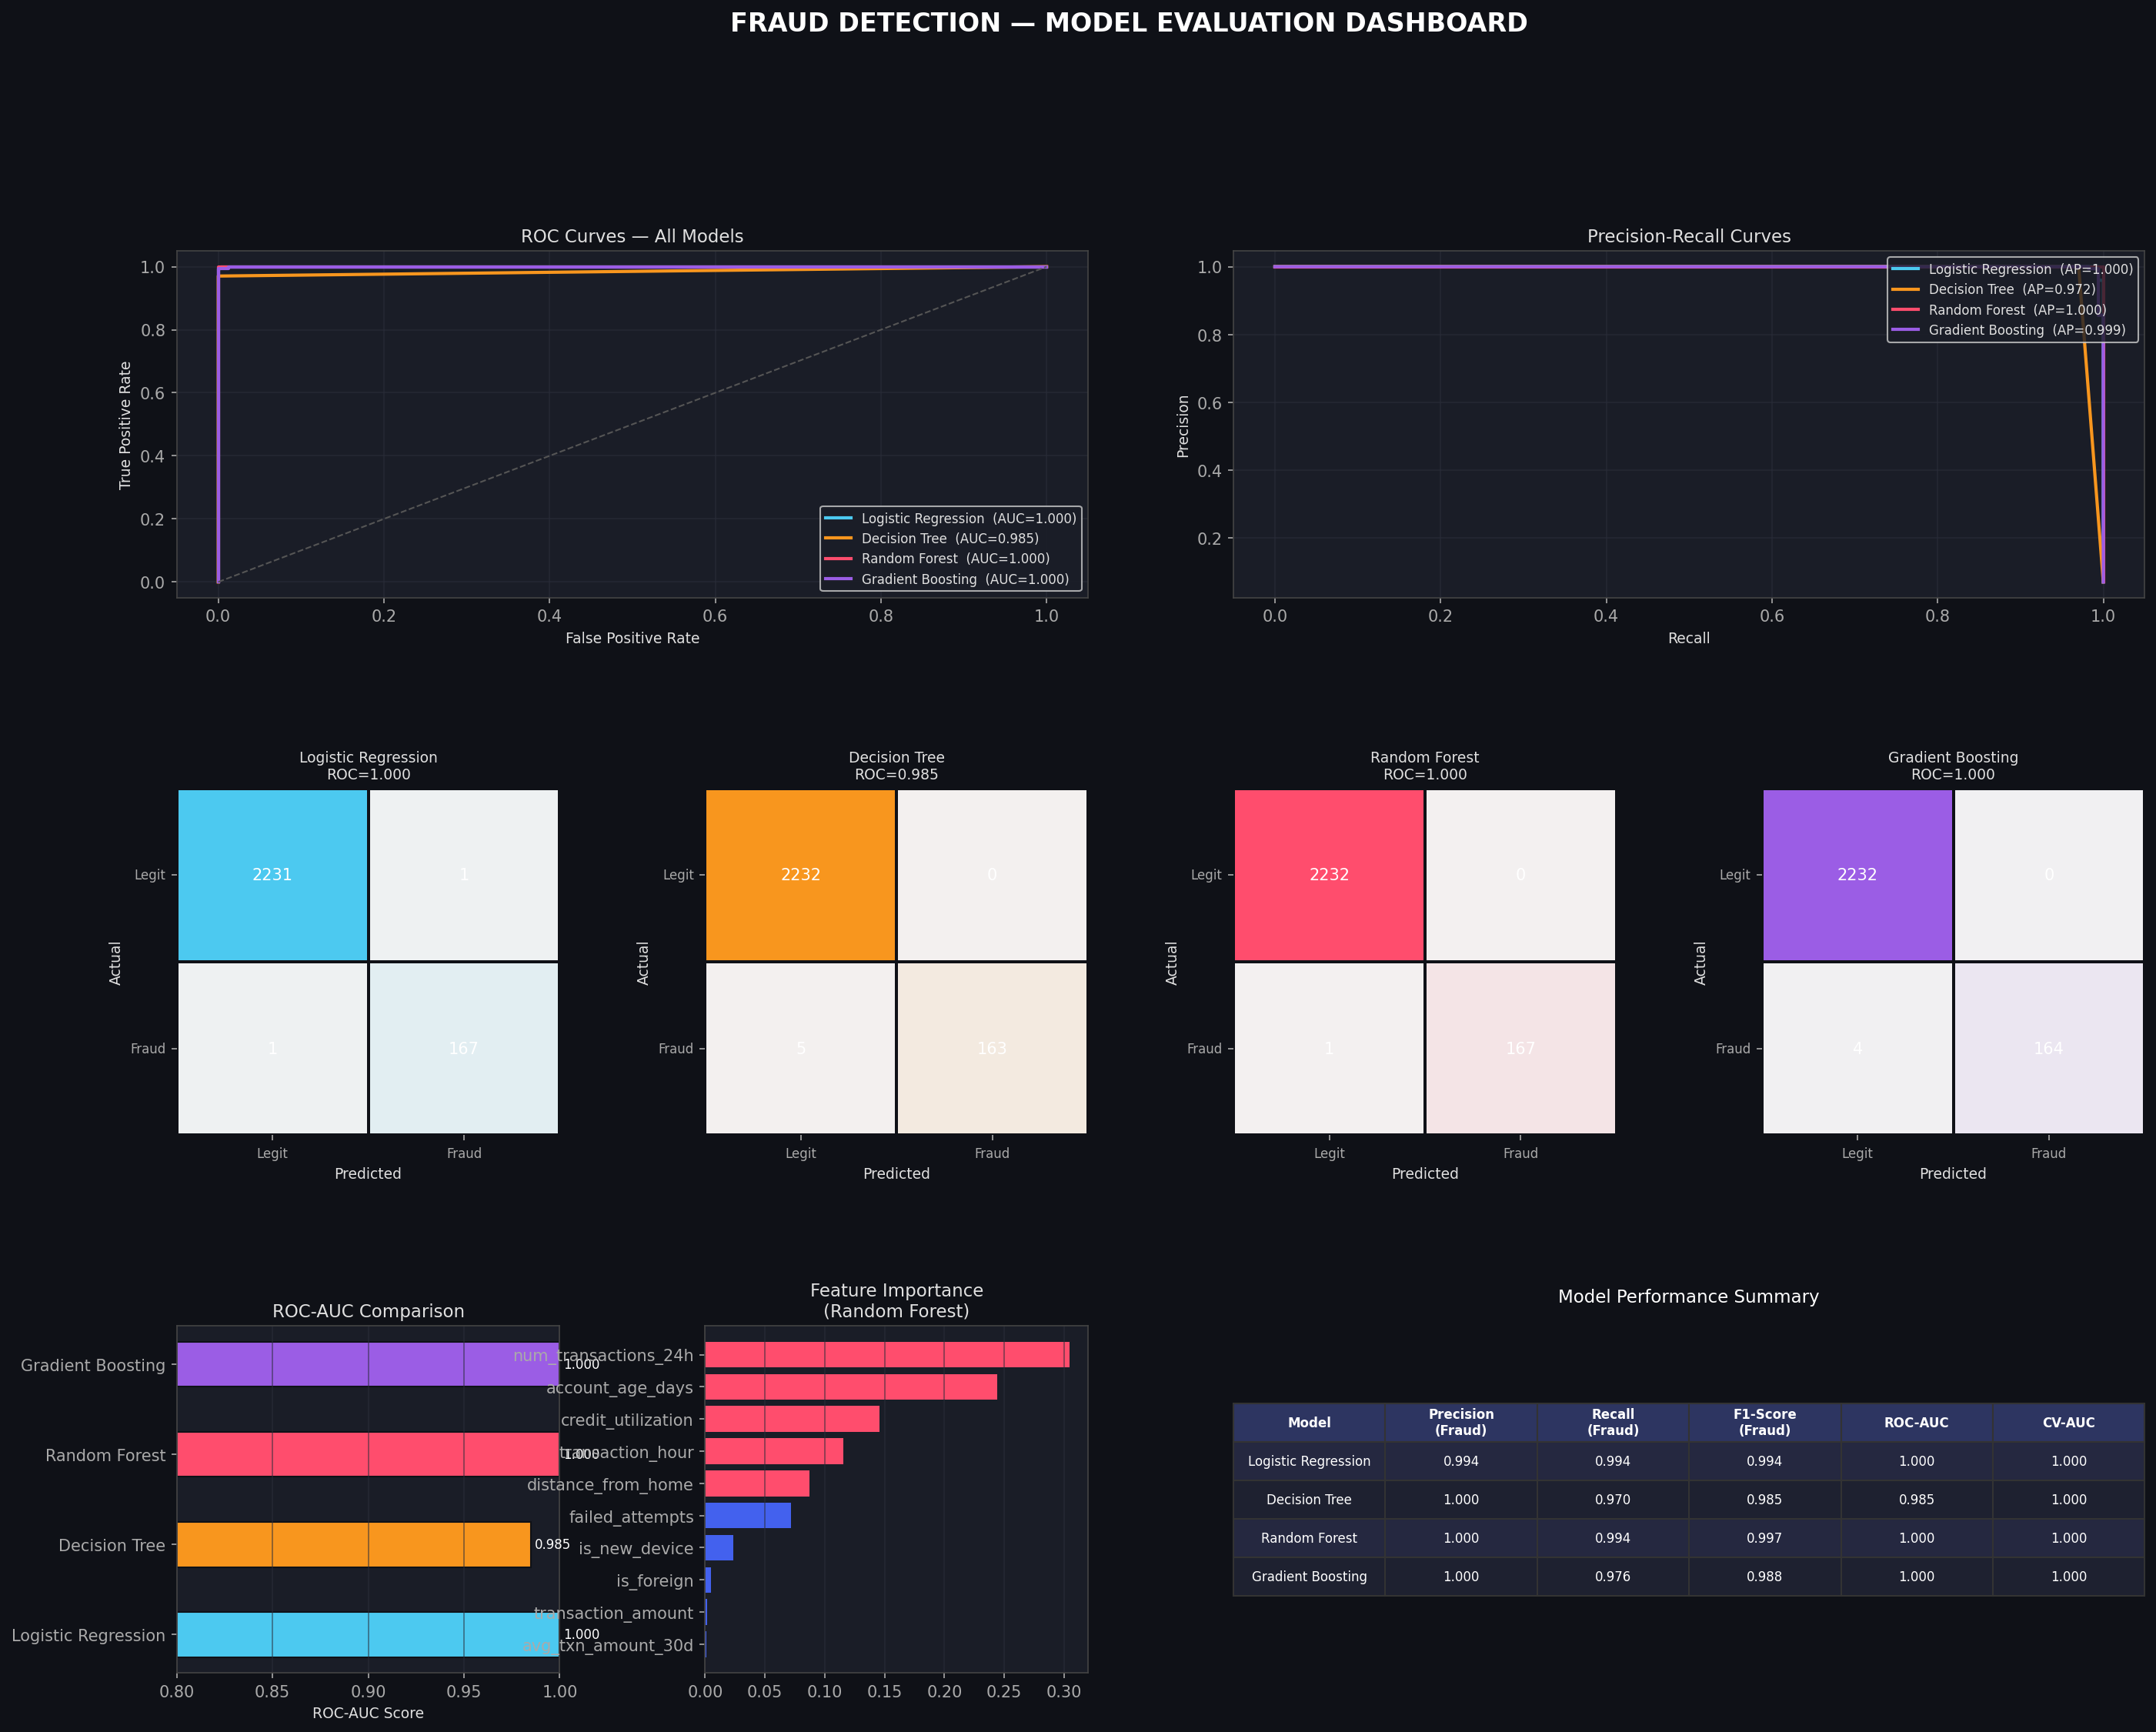

In [ ]:
from IPython.display import Image, display
display(Image('/content/results.png'))

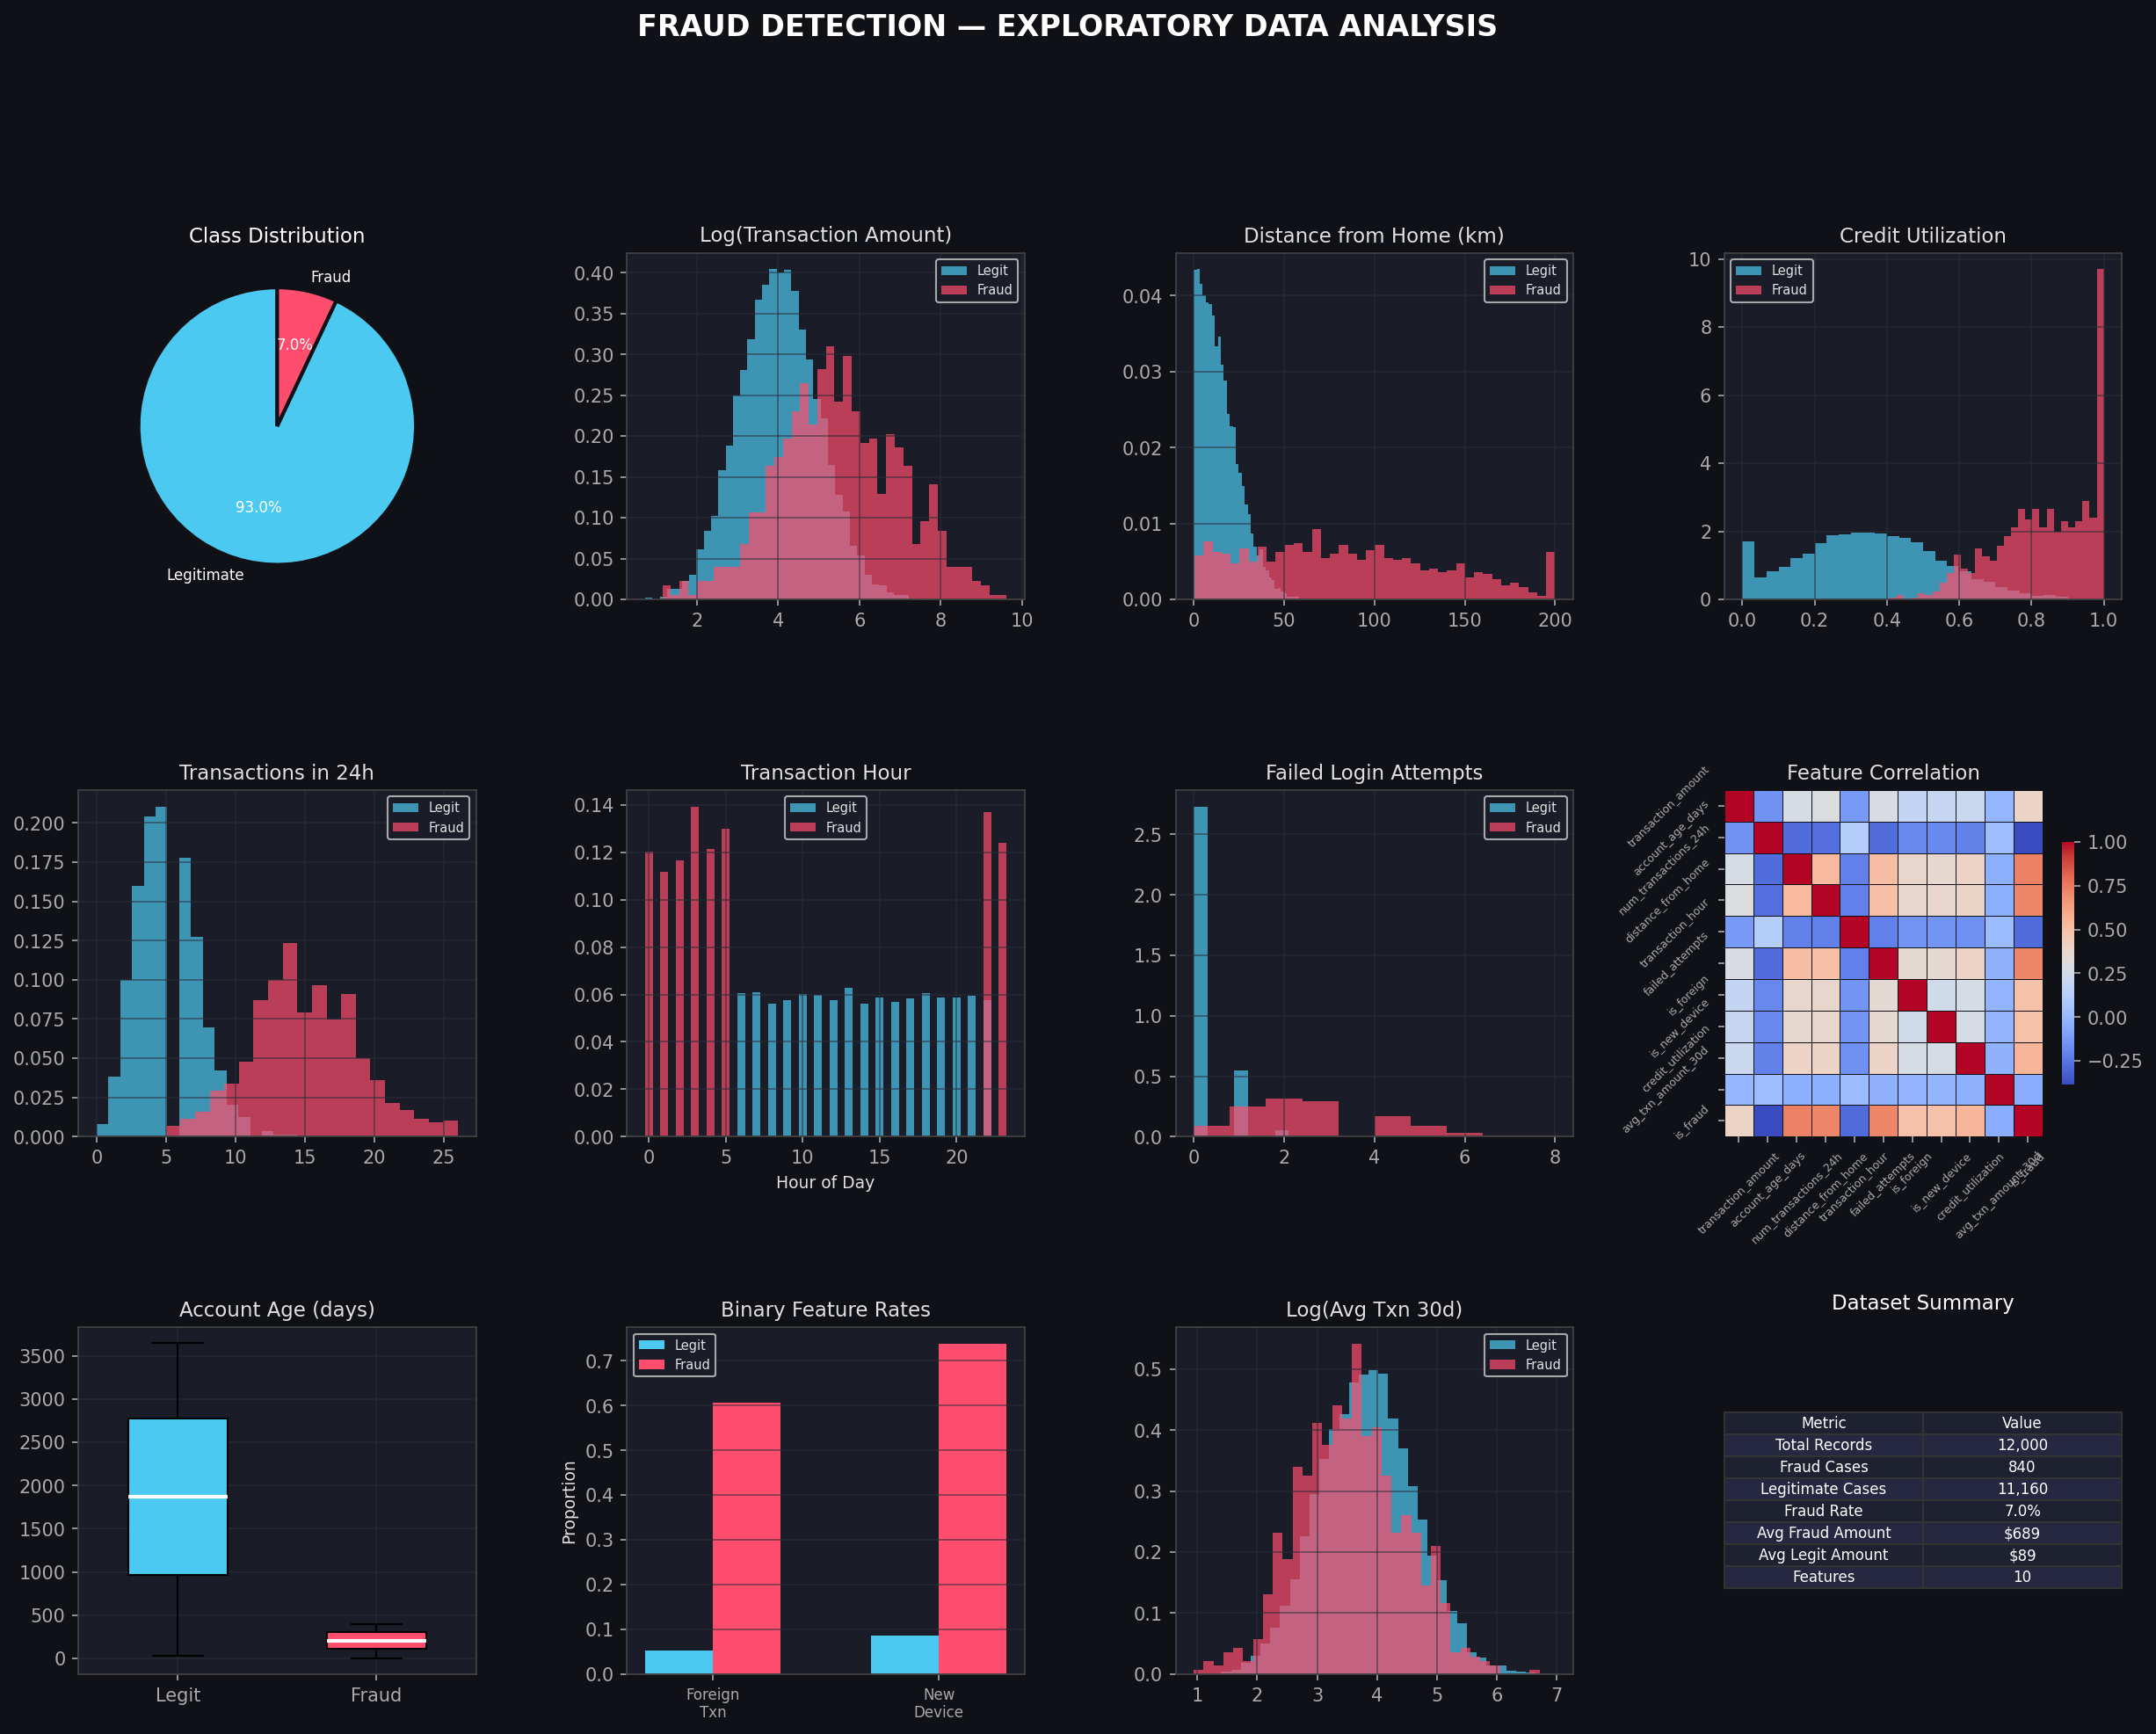

In [ ]:
from IPython.display import Image, display
display(Image('/content/eda.png'))

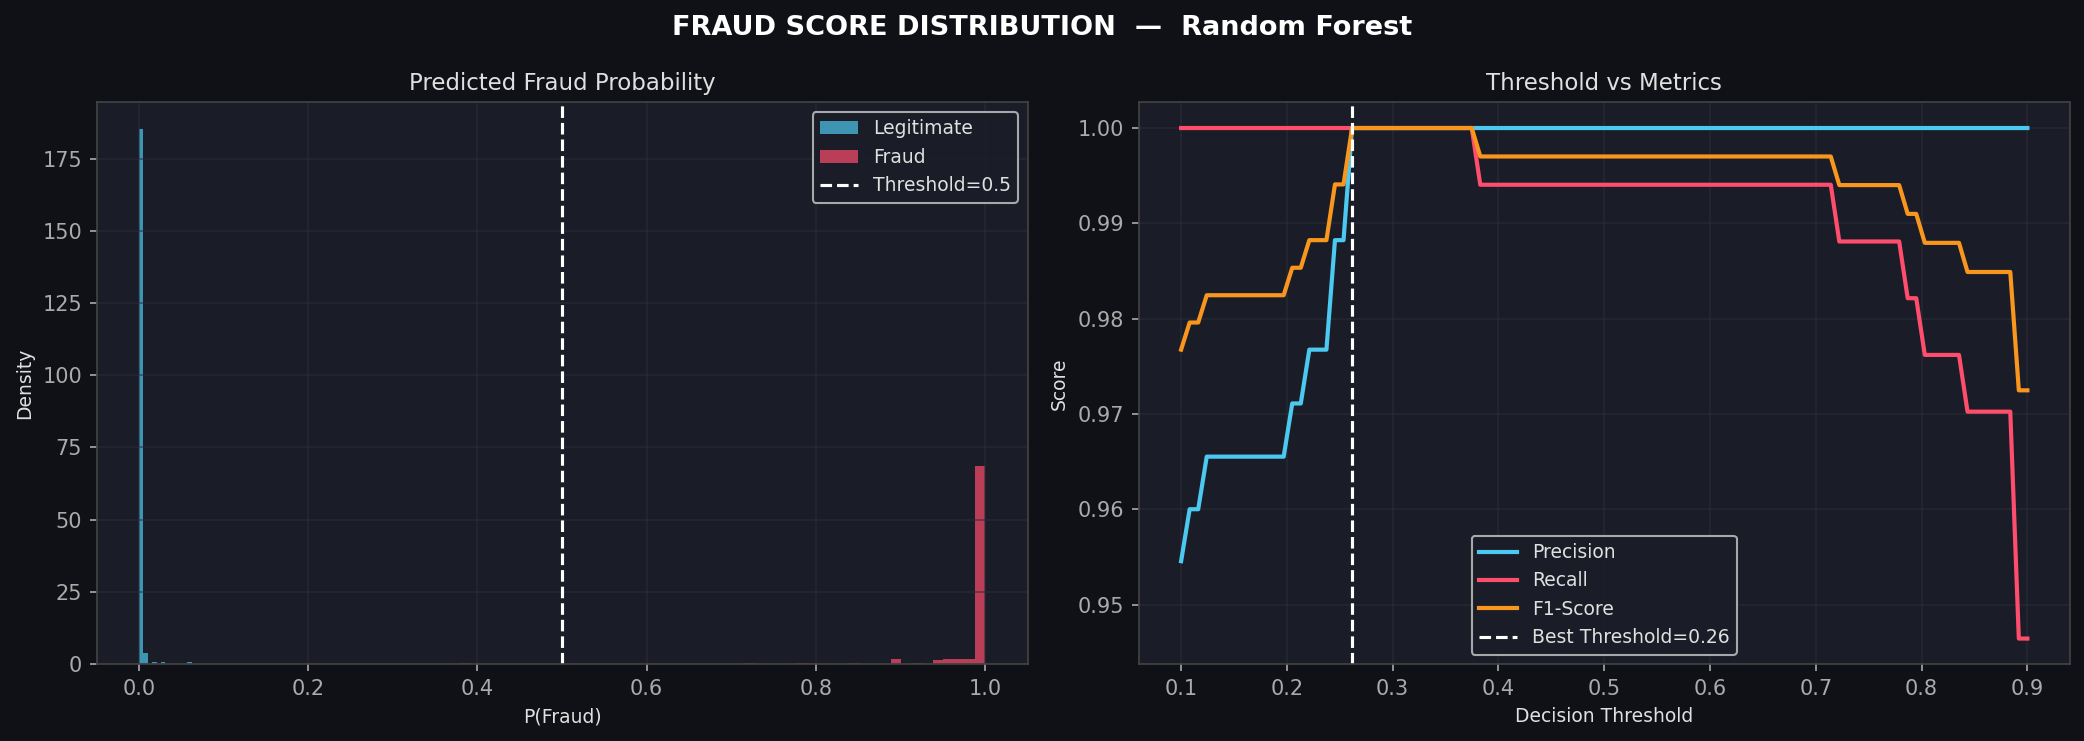

In [ ]:
from IPython.display import Image, display
display(Image('/content/scores.png'))